<a href="https://colab.research.google.com/github/Geethika1205/Generative_AI_2025/blob/main/HST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving combined_dataset (1).zip to combined_dataset (1).zip


In [2]:
import os
import zipfile
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# Unzip dataset
zip_path = '/content/combined_dataset (1).zip'
extract_path = '/mnt/data/combined_dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Load data
input_images = []
target_images = []

for file_name in sorted(os.listdir(extract_path)):
    img = cv2.imread(os.path.join(extract_path, file_name))
    if img is None: continue

    # Assuming side-by-side image split
    w = img.shape[1] // 2
    input_img = cv2.resize(img[:, :w], (128, 128))
    target_img = cv2.resize(img[:, w:], (128, 128))

    input_images.append(input_img)
    target_images.append(target_img)

# Normalize and convert to arrays
input_images = np.array(input_images) / 255.0
target_images = np.array(target_images) / 255.0

X_train, X_val, y_train, y_val = train_test_split(input_images, target_images, test_size=0.1, random_state=42)


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

def spatial_attention(x):
    avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
    concat = tf.concat([avg_pool, max_pool], axis=-1)
    return layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

def temporal_attention(x):
    b, h, w, c = x.shape
    x_reshaped = tf.reshape(x, [b, h * w, c])
    attn = tf.keras.layers.Attention()([x_reshaped, x_reshaped])
    return tf.reshape(attn, [b, h, w, c])

def multi_scale_curve_encoder(x, filters):
    x1 = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x2 = layers.Conv2D(filters, 5, padding='same', activation='relu')(x)
    x3 = layers.Conv2D(filters, 7, padding='same', activation='relu')(x)
    return layers.Concatenate()([x1, x2, x3])


In [4]:
def build_hsta_mce(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = multi_scale_curve_encoder(inputs, 32)
    x = layers.MaxPooling2D()(x)

    x = multi_scale_curve_encoder(x, 64)
    x = layers.MaxPooling2D()(x)

    # Attention Bottleneck
    sa = spatial_attention(x)
    ta = temporal_attention(x)
    x = layers.Multiply()([x, sa])
    x = layers.Add()([x, ta])

    # Decoder
    x = layers.UpSampling2D()(x)
    x = multi_scale_curve_encoder(x, 64)

    x = layers.UpSampling2D()(x)
    x = multi_scale_curve_encoder(x, 32)

    outputs = layers.Conv2D(3, kernel_size=1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model


In [5]:
def spatial_attention_layer():
    def layer(x):
        avg_pool = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
        max_pool = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
        return layers.Multiply()([x, attention])
    return layer


In [6]:
def temporal_attention_layer():
    def layer(x):
        shape = tf.keras.backend.int_shape(x)
        b, h, w, c = shape
        flatten = layers.Reshape((h * w, c))(x)
        attention_out = layers.Attention()([flatten, flatten])
        return layers.Reshape((h, w, c))(attention_out)
    return layer


In [7]:
def build_hsta_mce(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = multi_scale_curve_encoder(inputs, 32)
    x = layers.MaxPooling2D()(x)

    x = multi_scale_curve_encoder(x, 64)
    x = layers.MaxPooling2D()(x)

    # Hybrid Attention Bottleneck
    sa = spatial_attention_layer()(x)
    ta = temporal_attention_layer()(x)
    x = layers.Add()([sa, ta])  # Combine both attentions

    # Decoder
    x = layers.UpSampling2D()(x)
    x = multi_scale_curve_encoder(x, 64)

    x = layers.UpSampling2D()(x)
    x = multi_scale_curve_encoder(x, 32)

    outputs = layers.Conv2D(3, kernel_size=1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs)


In [8]:
model = build_hsta_mce()
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=8
)


Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 53s 760ms/step - loss: 0.0937 - mae: 0.2535 - val_loss: 0.0388 - val_mae: 0.1511
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - loss: 0.0338 - mae: 0.1410 - val_loss: 0.0272 - val_mae: 0.1225
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - loss: 0.0274 - mae: 0.1215 - val_loss: 0.0223 - val_mae: 0.1085
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 0.0219 - mae: 0.1048 - val_loss: 0.0181 - val_mae: 0.0916
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - loss: 0.0199 - mae: 0.0963 - val_loss: 0.0164 - val_mae: 0.0880
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 0.0179 - mae: 0.0893 - val_loss: 0.0162 - val_mae: 0.0847
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - loss: 0.0163 - mae: 0.0829 - val_loss: 0.0134 - val_mae: 0.0716
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - loss: 0.0149 - mae: 0.0778 - val_loss: 0.0136 - val_mae: 0.0783
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/st

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


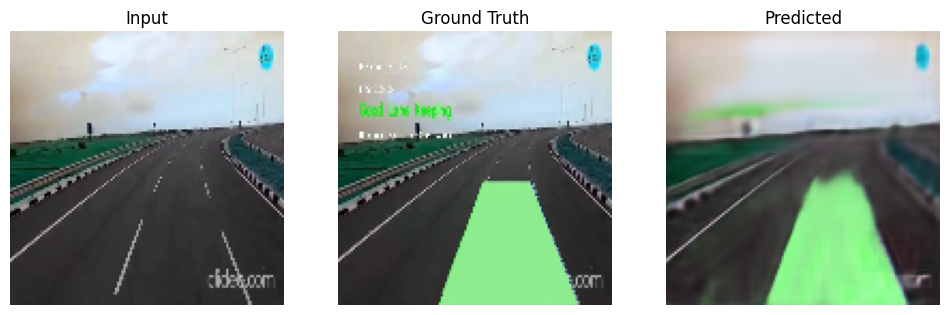

In [9]:
import matplotlib.pyplot as plt

i = np.random.randint(0, len(X_val))
pred = model.predict(X_val[i:i+1])[0]

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Input")
plt.imshow(X_val[i])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(y_val[i])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Predicted")
plt.imshow(pred)
plt.axis('off')
plt.show()


In [10]:
loss, mae = model.evaluate(X_val, y_val)
print("Validation MAE:", mae)


2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0074 - mae: 0.0487
Validation MAE: 0.04895097017288208


In [11]:
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim
import numpy as np

# Predict some images
predictions = model.predict(X_val)

def psnr(gt, pred):
    return tf.image.psnr(gt, pred, max_val=1.0).numpy().mean()

def ssim_score(gt, pred):
    scores = []
    for i in range(len(gt)):
        score = ssim(gt[i], pred[i], channel_axis=2, data_range=1.0)
        scores.append(score)
    return np.mean(scores)

print("PSNR:", psnr(y_val, predictions))
print("SSIM:", ssim_score(y_val, predictions))


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 956ms/step
PSNR: 21.462128
SSIM: 0.6857963885908512


In [12]:
def pixel_accuracy(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.float32)
    return np.mean(y_pred == y_true)

print("Pixel Accuracy:", pixel_accuracy(y_val, predictions))


Pixel Accuracy: 0.0028285606234681373


In [13]:
import numpy as np

def percentage_accuracy(y_true, y_pred, tolerance=0.05):
    """
    Computes pixel-wise accuracy with tolerance.
    y_true and y_pred should be numpy arrays scaled in [0, 1]
    tolerance: allowable absolute error per channel
    """
    correct_pixels = np.abs(y_true - y_pred) <= tolerance
    accuracy = np.mean(correct_pixels) * 100
    return accuracy

# Predict validation set
predictions = model.predict(X_val)

# Compute accuracy
acc = percentage_accuracy(y_val, predictions)
print(f"Pixel-wise Accuracy: {acc:.2f}%")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step 
Pixel-wise Accuracy: 72.72%


In [14]:
def mask_accuracy(y_true, y_pred, threshold=0.5):
    y_true_bin = (y_true > 0.5).astype(np.uint8)
    y_pred_bin = (y_pred > threshold).astype(np.uint8)
    return np.mean(y_true_bin == y_pred_bin) * 100

acc = mask_accuracy(y_val, predictions)
print(f"Mask Accuracy: {acc:.2f}%")


Mask Accuracy: 94.39%
